In [219]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [220]:
df=pd.read_csv(r"C:\Users\SIDDHARTHA\Downloads\website_traffic_2025_dataset.csv.xls")
df

,Date,Sessions,Bounce_Rate,Pages,Visitors
0,2025-01-01,302,49.43,4.71,283
1,2025-01-02,635,48.54,4.74,573
2,2025-01-03,1060,38.46,6.01,824
3,2025-01-04,470,33.26,4.11,434
4,2025-01-05,306,61.40,3.04,259
...,...,...,...,...,...
360,2025-12-27,462,53.51,5.00,437
361,2025-12-28,963,48.21,4.14,749
362,2025-12-29,343,57.03,4.71,291
363,2025-12-30,545,48.21,4.24,476


In [221]:
# To check variable/coloumn data types
df.dtypes

Date            object
Sessions         int64
Bounce_Rate    float64
Pages          float64
Visitors         int64
dtype: object

In [222]:
df.duplicated().sum()

np.int64(0)

In [223]:
# To show column wise total missing values(null)
df.isnull().sum()


Date           0
Sessions       0
Bounce_Rate    0
Pages          0
Visitors       0
dtype: int64

In [224]:
# To see discreptive stats of df
df.describe()

,Sessions,Bounce_Rate,Pages,Visitors
count,365.000000,365.000000,365.000000,365.000000
mean,708.550685,48.362548,4.362767,604.810959
std,282.014108,10.519602,1.122588,245.350097
min,201.000000,30.180000,2.520000,151.000000
25%,467.000000,39.830000,3.340000,404.000000
50%,705.000000,49.380000,4.290000,609.000000
75%,948.000000,57.710000,5.280000,803.000000
max,1196.000000,64.990000,6.490000,1086.000000


In [225]:
df.head()

,Date,Sessions,Bounce_Rate,Pages,Visitors
0,2025-01-01,302,49.43,4.71,283
1,2025-01-02,635,48.54,4.74,573
2,2025-01-03,1060,38.46,6.01,824
3,2025-01-04,470,33.26,4.11,434
4,2025-01-05,306,61.40,3.04,259


In [226]:
df['Date'] = pd.to_datetime(df['Date'])

# visulazation

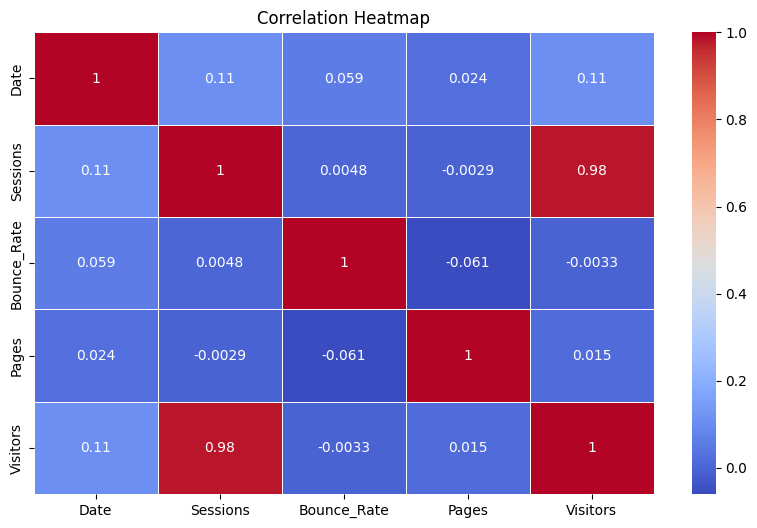

In [227]:
# Visualize the data by using heatmap to check the correlation between the features
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

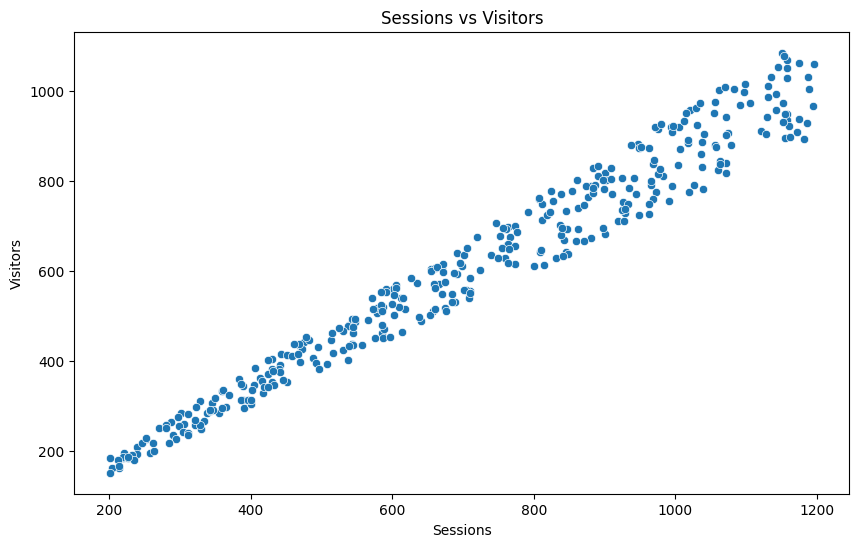

In [260]:
# Visualize the data by using scatter plot to check the relationship between the features
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sessions', y='Visitors', data=df)
plt.title('Sessions vs Visitors')
plt.xlabel('Sessions')
plt.ylabel('Visitors')
plt.show()

# machine learning

In [261]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [262]:
df.head()

,Date,Sessions,Bounce_Rate,Pages,Visitors
0,2025-01-01,302,49.43,4.71,283
1,2025-01-02,635,48.54,4.74,573
2,2025-01-03,1060,38.46,6.01,824
3,2025-01-04,470,33.26,4.11,434
4,2025-01-05,306,61.40,3.04,259


In [263]:
x = df[['Sessions']].values   # Independent variables
y = df['Visitors'].values         # Target variable

In [264]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [265]:
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [266]:
#calculating mae(mean absolute error)
mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)
#calculating mse(mean squarred error)
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)
#calculating r2_score
r2=r2_score(y_test,y_pred)
print("R2 Score:",r2)

MAE: 32.01042534543152
MSE: 1526.0287477849067
R2 Score: 0.971265113656492


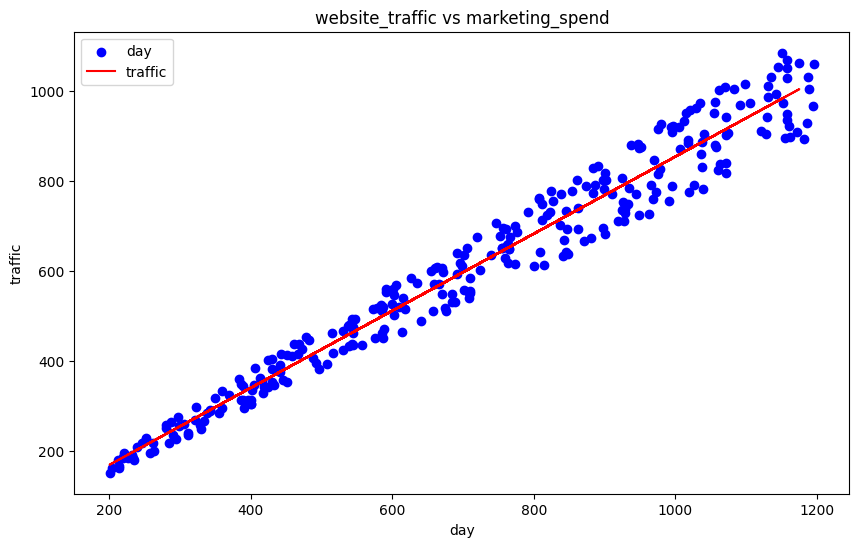

In [267]:
plt.figure(figsize=(10, 6))
plt.scatter(x_train[:,0],y_train,color='blue',label='day')
plt.plot(x_test[:,0],y_pred,color='red',label='traffic')
plt.xlabel('day')
plt.ylabel('traffic')
plt.title('website_traffic vs marketing_spend')
plt.legend()
plt.show()

In [256]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 2)
x_poly = poly_reg.fit_transform(x)


In [257]:
x1_train, x1_test, y1_train, y1_test = train_test_split(x_poly, y, test_size=0.2, random_state=42)

In [258]:

lin_reg2 = LinearRegression()
lin_reg2.fit(x1_train, y1_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


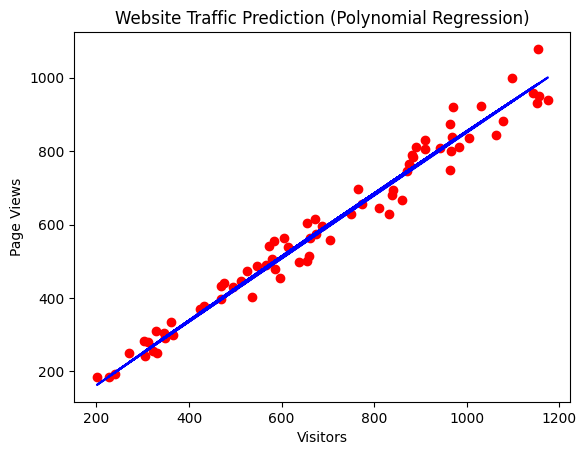

In [259]:
# Visualising Polynomial Regression results for Website Traffic Prediction
plt.scatter(x_test[:,0],y_test, color='red')   # Actual traffic data
plt.plot(x_test[:,0], lin_reg2.predict(x1_test), color='blue')  # Predicted traffic

plt.title('Website Traffic Prediction (Polynomial Regression)')
plt.xlabel('Visitors')      # or Sessions / Date
plt.ylabel('Page Views')    # or Traffic
plt.show()